# Test Pearson over SRJD with type-2 conditon

In [1]:
from ajdmom.mdl_srjd.cond2_cmom import cmoment_v, poly2num
from ajdmom.mdl_srjd.cond2_mom import moment_v
from ajdmom.mdl_srjd.euler import rSRJD
import matplotlib.pyplot as plt

import numpy as np
from pprint import pprint
from pearsondist import Pearson8, Support8

from utils import plot_pdf_cdf, plot_dpdf_pdf

rng = np.random.default_rng()


In [2]:
# Parameters
# theta = 0.008
theta = 0.018
v0, k, sigma = 0.007569, 3.46, 0.14
lmbd, mu_v, h = 0.47, 0.05, 1.0

par = {'v0': v0, 'h': h, 'k': k, 'theta': theta, 'sigma': sigma, 'mu_v': mu_v, 'lmbd': lmbd}

In [3]:
num_jumps = rng.poisson(lmbd * h)
num_jumps = 3
jumptimes = sorted(rng.uniform(0, h, num_jumps))
jumptimes = [float(jumptime) for jumptime in jumptimes]
jumpsizes = rng.exponential(mu_v, num_jumps)
jumpsizes = [float(jumpsize) for jumpsize in jumpsizes]

par['jumptime'] = jumptimes
par['jumpsize'] = jumpsizes
print(f'jump times: {jumptimes}')
print(f'jump sizes: {jumpsizes}')

jump times: [0.1628206702459436, 0.6251359743837481, 0.9791779637716239]
jump sizes: [0.019122138029318485, 0.05039616345976772, 0.014863827998068868]


## Central Moments

In [4]:
moms = [poly2num(cmoment_v(i), par) for i in range(1, 9)]
print(f'moms: {moms}')

moms: [0.0, 0.00011693364746635183, 6.718559706113397e-07, 4.6668498323436736e-08, 8.47103205703126e-10, 3.922628227937834e-11, 1.2614655102707354e-12, 5.699297981527948e-14]


{'A1': np.float64(27.14767337820676),
 'A2': np.float64(-13.421752798919584),
 'A3': np.float64(-13.725920579287179),
 'B3': np.float64(7.127220091187904),
 'type': 44,
 'x1': np.float64(-0.15615937970921023),
 'x2': np.float64(-0.040465762918148164),
 'x3': np.complex128(0.12498169805030834+0.15308718163645024j)}
a = 0.0028970064089257584, scale = 9.347435810828056
is_max: True
pdf(-a) = 1.0000000
iteration: 0, x0 =   -0.0237943
iteration: 1, x0 =   -0.0260857
iteration: 2, x0 =   -0.0278624
iteration: 3, x0 =   -0.0293057
iteration: 4, x0 =   -0.0305116
iteration: 5, x0 =   -0.0315385
iteration: 6, x0 =   -0.0324251
iteration: 7, x0 =   -0.0331986
iteration: 8, x0 =   -0.0338791
iteration: 9, x0 =   -0.0344816
iteration: 10, x0 =   -0.0350180
iteration: 0, x0 =    0.0180138
iteration: 1, x0 =    0.0261035
iteration: 2, x0 =    0.0327202
iteration: 3, x0 =    0.0386245
iteration: 4, x0 =    0.0440825
iteration: 5, x0 =    0.0492272
iteration: 6, x0 =    0.0541370
iteration: 7, x0 =   

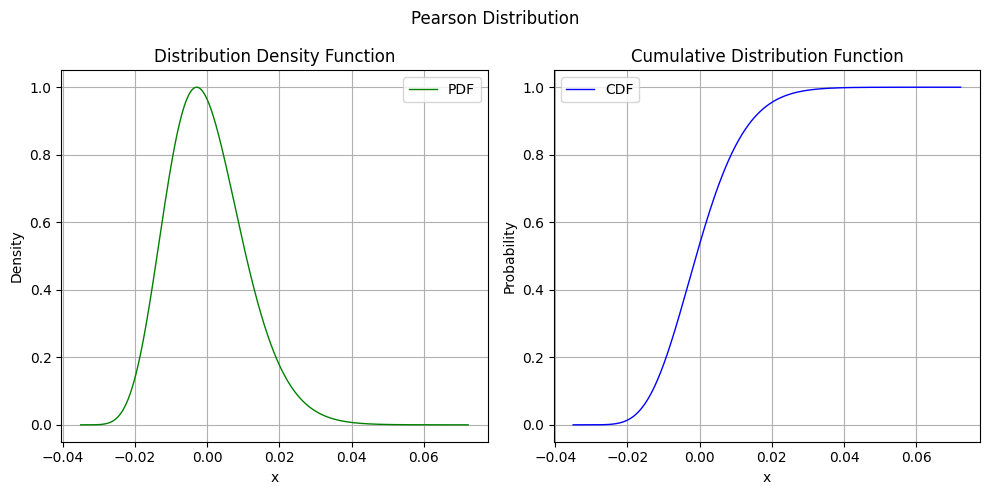

pdf(-0.0350180) = 7.13e-07, pdf(0.0722607) = 7.32e-06


In [5]:
pearson = Pearson8(moms)
pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
print(f'is_max: {pearson.pdf_obj.is_max}')
print(f'pdf(-a) = {pearson.pdf(-pearson.coef[0]):.7f}')
lbub = pearson.determine_bounds()

# lbub = (-0.03966, 0.1)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
# support8 = Support8(pearson.pdf_obj)
# bounds = support8.determine_bounds()
# print(f'bounds: ({bounds[0]:.5f},{bounds[1]:.5f})')

# roots = support8.pdf_obj.ddpdf_roots()
# plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Raw Moments

moms: [0.046333913241767985, 0.002263765163762035, 0.00011639694162159702, 6.286293960873975e-06, 3.5594528484745435e-07, 2.1092677847120223e-08, 1.305868054500753e-09, 8.432982901217214e-11]


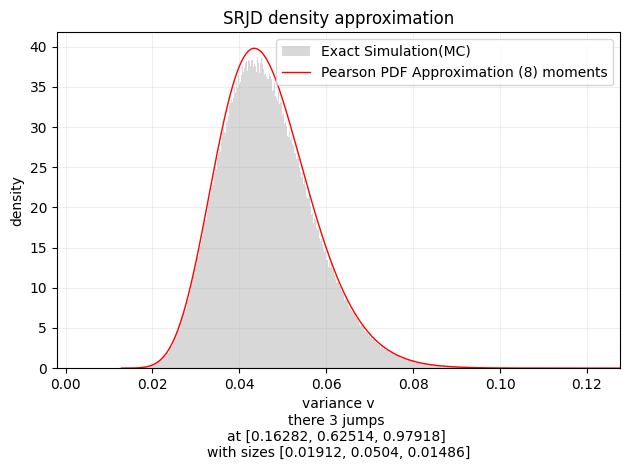

In [6]:
vt = rSRJD(v0, k, theta, sigma, h, jumpsizes, jumptimes, 1000 * 1000)

moms = [poly2num(moment_v(i), par) for i in range(1, 9)]
print(f'moms: {moms}')

v_max = max(vt)
v_min = min(vt)
v_grid = np.linspace(v_min, v_max, 1000)

pearson = Pearson8(moms[:8])
pdf = pearson.pdf(v_grid)

hist, bin_edges = np.histogram(vt, bins=1000, density=True)
hist_max = np.max(hist)
# pdf_max = np.max(pdf)
pdf_max = 1
scaling_factor = hist_max / pdf_max
scaled_pdf = pdf * scaling_factor


plt.hist(vt, bins=1000, density=True, alpha=0.3, color='gray', label='Exact Simulation(MC)')
plt.plot(v_grid, scaled_pdf, 'r-', lw=1, label=f'Pearson PDF Approximation ({len(moms)}) moments')
plt.xlim(-0.002, v_max)
# plt.ylim()
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.title('SRJD density approximation')
jumptime = [round(time, 5) for time in jumptimes]
jumpsize = [round(size, 5) for size in jumpsizes]
plt.xlabel(f'variance v\nthere {num_jumps} jumps \nat {jumptime} \nwith sizes {jumpsize}')
plt.ylabel('density')
plt.legend()
plt.grid(alpha= 0.2)
plt.tight_layout()
plt.show()